#SME0142 - Álgebra Linear e Aplicações
##Google Page Rank
####Docente: Cynthia de Oliveira Lage Ferreira
ICMC - USP São Carlos

Páginas da web podem ser representadas como um grafo direcionado.

- Uma página é importante se páginas importantes têm link para ela;
- Eleição: um link de $A \to B$ é um voto de A para B;
- Visão probabilística do Pagerank: é a probabilidade de uma página web
ser visitada em certo instante de tempo durante um passeio aleatório
infinito.

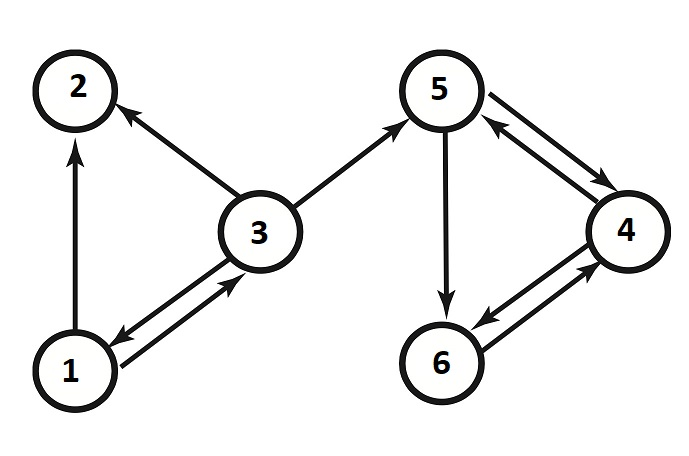

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

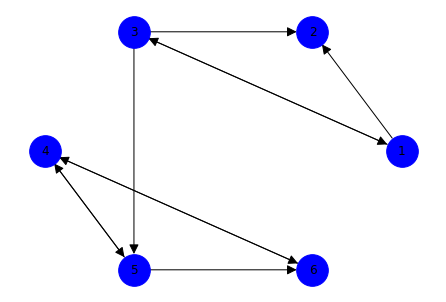

In [3]:
g = nx.DiGraph()
g.add_nodes_from([1,2,3,4,5,6])

g.add_edge(1,2)
g.add_edge(1,3)
g.add_edge(3,1)
g.add_edge(3,2)
g.add_edge(3,5)
g.add_edge(5,4)
g.add_edge(5,6)
g.add_edge(4,5)
g.add_edge(4,6)
g.add_edge(6,4)

options = {
    'node_color': 'blue',
    'node_size': 1000,
    'width': 1,
    'arrowstyle': '-|>',
    'arrowsize': 20,
}

npos=nx.circular_layout(g,scale=1)

nx.draw(g,pos = npos, with_labels=True, **options, arrows=True)
plt.show()

In [8]:
A = np.transpose(nx.to_numpy_matrix(g))
print(A)

[[0. 0. 1. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1.]
 [0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 1. 1. 0.]]


In [10]:
N = A.shape[0]
P = np.zeros((N,N))
for i in range(0,N):
    for j in range(0,N):
        if(np.sum(A[:,j]) > 0):
            P[i,j] = A[i,j]/np.sum(A[:,j])
        else:
            P[i,j] = 1/N
print(P)

[[0.         0.16666667 0.33333333 0.         0.         0.        ]
 [0.5        0.16666667 0.33333333 0.         0.         0.        ]
 [0.5        0.16666667 0.         0.         0.         0.        ]
 [0.         0.16666667 0.         0.         0.5        1.        ]
 [0.         0.16666667 0.33333333 0.5        0.         0.        ]
 [0.         0.16666667 0.         0.5        0.5        0.        ]]


In [11]:
G = np.zeros((N,N))
alpha = 0.85
for i in range(0,N):
    for j in range(0,N):
        G[i,j] = alpha*P[i,j] + (1-alpha)/N
print(G)

[[0.025      0.16666667 0.30833333 0.025      0.025      0.025     ]
 [0.45       0.16666667 0.30833333 0.025      0.025      0.025     ]
 [0.45       0.16666667 0.025      0.025      0.025      0.025     ]
 [0.025      0.16666667 0.025      0.025      0.45       0.875     ]
 [0.025      0.16666667 0.30833333 0.45       0.025      0.025     ]
 [0.025      0.16666667 0.025      0.45       0.45       0.025     ]]


In [15]:
eigvals, eigvecs = np.linalg.eig(G)
eigvec1 = eigvecs[:,np.isclose(eigvals, 1)]
eigvec1 = eigvec1[:,0]

stationary = eigvec1 / eigvec1.sum()

stationary = stationary.real
for i in range(0,N):
    print(i+1, ':', stationary[i])

1 : 0.0517047457570208
2 : 0.07367926270375492
3 : 0.0574124124964324
4 : 0.348703685214817
5 : 0.19990381197331852
6 : 0.2685960818546563


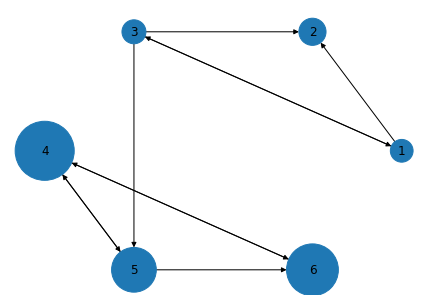

In [14]:
npos=nx.circular_layout(g,scale=1)

s = stationary*10000
nx.draw(g,pos = npos, with_labels=True, node_size = s, arrows=True)
plt.draw()
plt.show()